# Scaler를 사용해야 하는 이유
: 다차원의 변수 값을 비교분석하기 쉽게 만듬  
: 단위가 다르기 때문에 통일

# 결론: MinMaxScaler로 하자!

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('최종데이터_1차군집결과.csv',encoding='cp949').drop('토지유형',axis=1)

df['행정동코드']=df['행정동코드'].astype(object)
df['법정동코드']=df['법정동코드'].astype(object)
df['grid']=df['grid'].astype(object)

df

Gulim


,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,평균기온(°C),공시지가
0,13187,서울특별시,중랑구,면목2동,1107052,11260102,상봉동,10007.653660,1,2227.272727,0.002711,41336.27429,19,38,0.122297,0.2,3053235.294
1,13190,서울특별시,중랑구,면목2동,1107052,11260101,면목동,10007.655520,1,2227.272727,0.002711,41336.27429,19,38,0.217246,0.2,3554822.222
2,13194,서울특별시,중랑구,면목2동,1107052,11260101,면목동,6480.509401,1,2227.272727,0.002711,41336.27429,19,38,0.217246,0.2,3612395.349
3,13195,서울특별시,중랑구,면목2동,1107052,11260101,면목동,5857.305252,1,2227.272727,0.002711,41336.27429,19,38,0.217246,0.2,3186083.333
4,13197,서울특별시,중랑구,면목2동,1107052,11260101,면목동,6094.001933,1,2227.272727,0.002711,41336.27429,19,38,0.217246,0.2,3181000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11505,71476,서울특별시,송파구,위례동,1124082,11710109,장지동,4617.266177,0,1816.666667,0.001029,84263.96095,19,38,8.851150,0.6,5844666.667
11506,71477,서울특별시,송파구,위례동,1124082,11710109,장지동,214.748286,0,1816.666667,0.001029,84263.96095,19,38,8.851150,0.6,8020333.333
11507,71478,서울특별시,송파구,위례동,1124082,11710113,거여동,0.000000,0,1816.666667,0.001029,84263.96095,19,38,7.453273,0.6,4698000.000
11508,71479,서울특별시,송파구,위례동,1124082,11710113,거여동,0.000000,0,1816.666667,0.001029,84263.96095,19,38,7.453273,0.6,4080600.000



# 인당녹지면적
   면적            면적         면적
ㅡㅡㅡㅡㅡㅡ + ㅡㅡㅡㅡㅡㅡ+ ㅡㅡㅡㅡㅡ
(상봉동인구)   (면목동인구)  (동별인구)

# 평균
총생활인구	

# 평균
   면적         면적        면적
ㅡㅡㅡㅡㅡ + ㅡㅡㅡㅡㅡ+ ㅡㅡㅡㅡㅡ
(기초인구)   (기초인구)  (기초인구)





In [69]:
df2 = df.groupby('행정동').agg({'총생활인구':'mean','인당녹지면적':'mean','기초수급자_인구밀도':'mean'})

- 변수별 이상치 제거

{'whiskers': [<matplotlib.lines.Line2D at 0x2371e92a1c0>,
 'caps': [<matplotlib.lines.Line2D at 0x2371e92a760>,
 'boxes': [<matplotlib.lines.Line2D at 0x2371e91ceb0>,
 'medians': [<matplotlib.lines.Line2D at 0x2371e92ad00>,
 'fliers': [<matplotlib.lines.Line2D at 0x2371e92afd0>,
 'means': []}

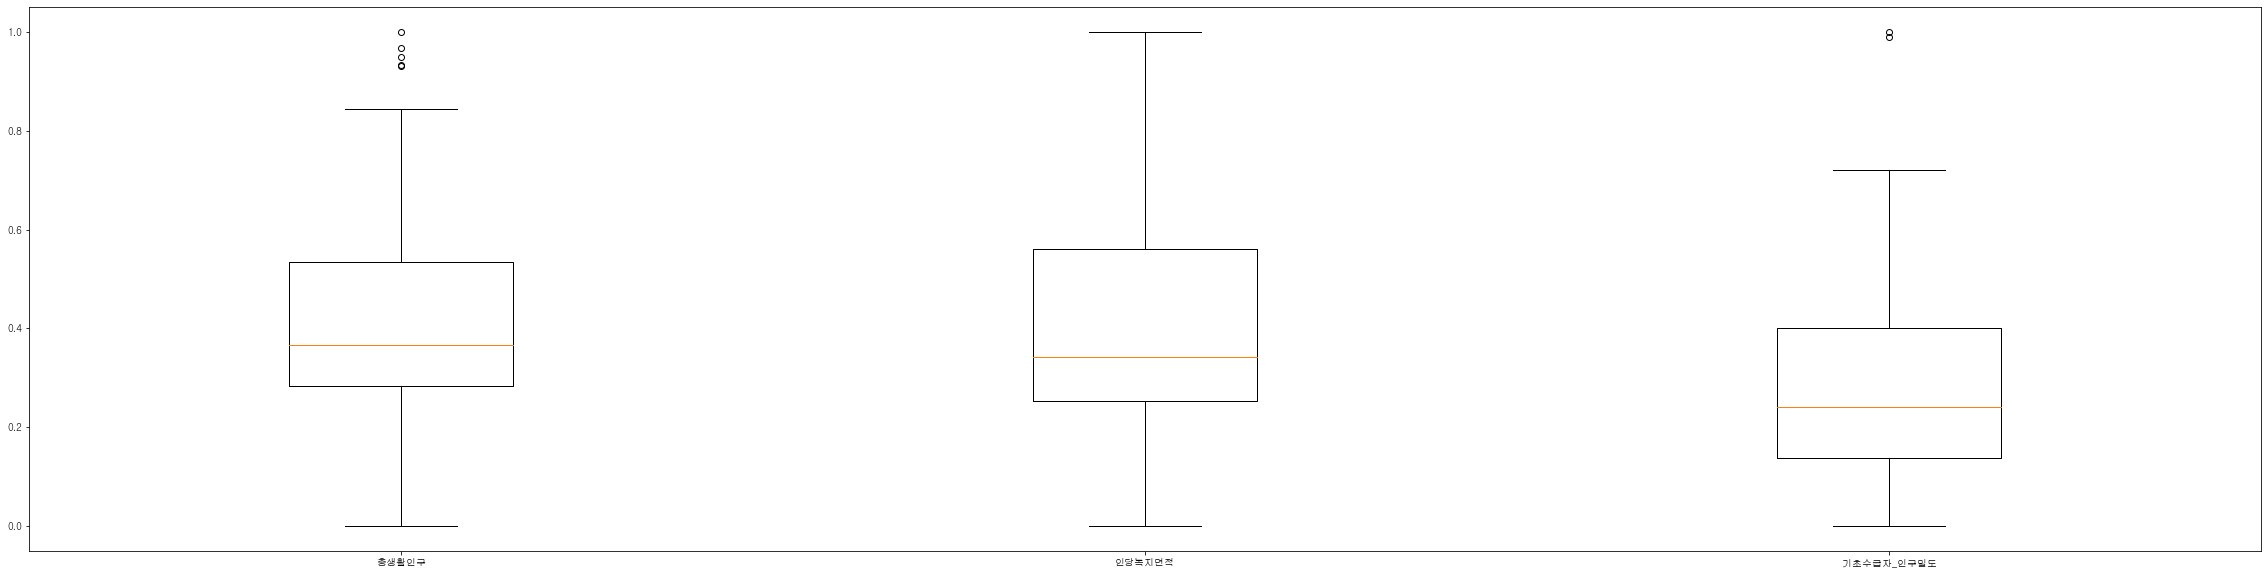

In [78]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df2) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df2.columns)

In [71]:
df2['인당녹지면적'] = np.log1p(df2['인당녹지면적'])

In [73]:
df2 = df2[df2.인당녹지면적 != df2.인당녹지면적.max()]
df2 = df2[df2.인당녹지면적 != df2.인당녹지면적.max()]

In [77]:
df2 = df2[df2.기초수급자_인구밀도 != df2.기초수급자_인구밀도.max()]
df2 = df2[df2.기초수급자_인구밀도 != df2.기초수급자_인구밀도.max()]

In [79]:
df2

,총생활인구,인당녹지면적,기초수급자_인구밀도
행정동,,,
가락1동,53481.18571,0.924458,83.582090
가락2동,49474.56286,1.046944,600.000000
가락본동,75267.14762,1.039169,653.982301
가양1동,98459.54190,2.448276,65.319149
가양2동,29146.41477,2.081538,3330.000000
...,...,...,...
화곡3동,39697.45905,1.820956,1277.358491
화곡4동,32927.02381,1.760130,1497.560976
화곡6동,39817.28714,1.765346,918.018018


{'whiskers': [<matplotlib.lines.Line2D at 0x2371daba190>,
 'caps': [<matplotlib.lines.Line2D at 0x2371daba6d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2371daabe80>,
 'medians': [<matplotlib.lines.Line2D at 0x2371dabac70>,
 'fliers': [<matplotlib.lines.Line2D at 0x2371dabaf40>,
 'means': []}

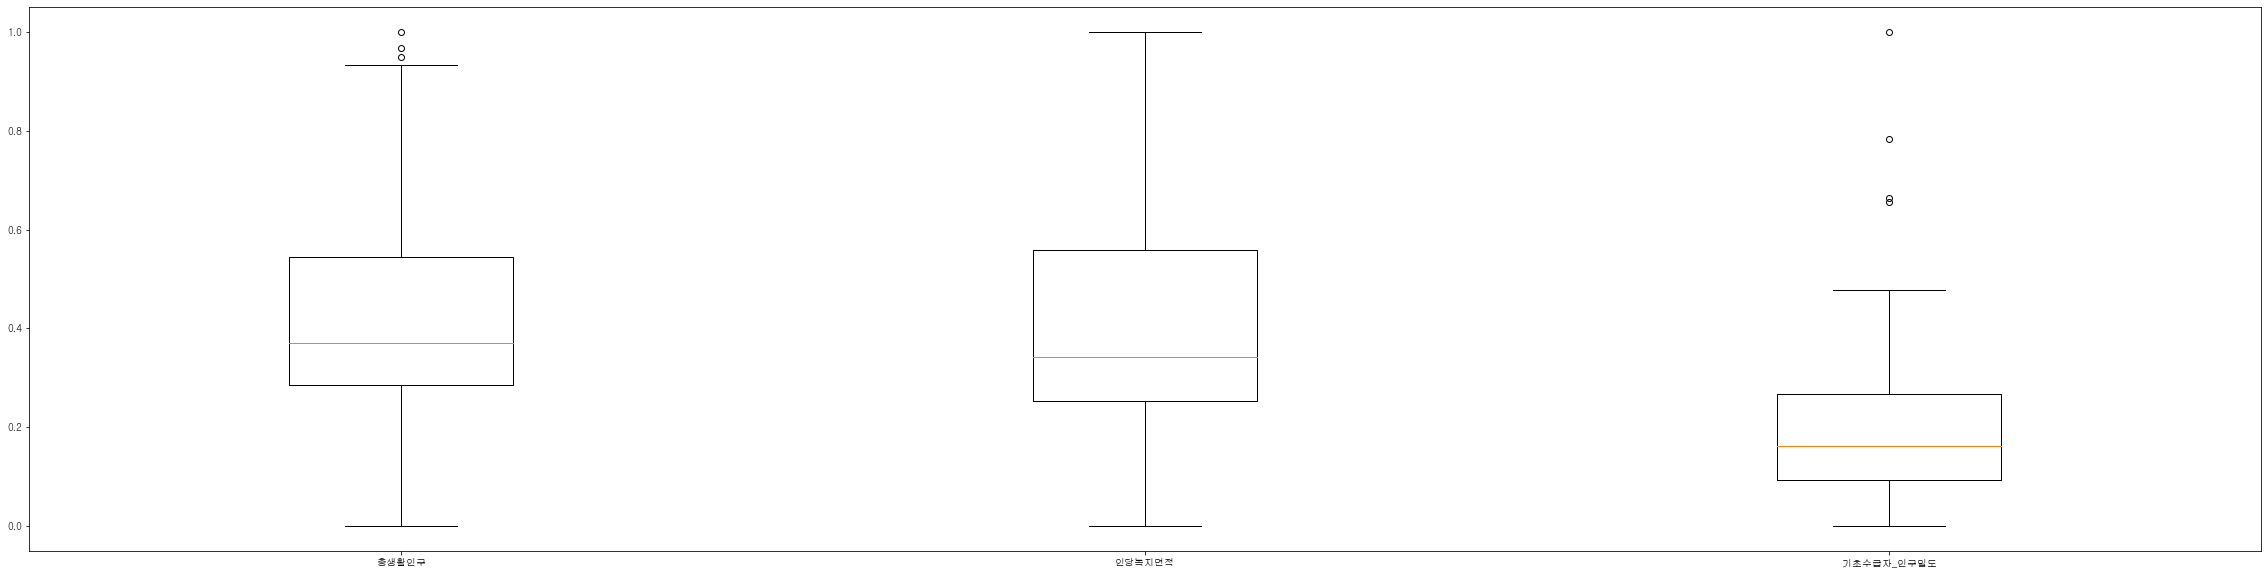

In [60]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df2) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df2.columns)

In [32]:
import numpy as np
df2['기초수급자_인구밀도'] = np.log1p(df2['기초수급자_인구밀도'])
df2['총생활인구'] = np.log1p(df2['총생활인구'])

In [35]:
df2['총생활인구'] = np.log1p(df2['총생활인구'])

C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='기초수급자_인구밀도'>

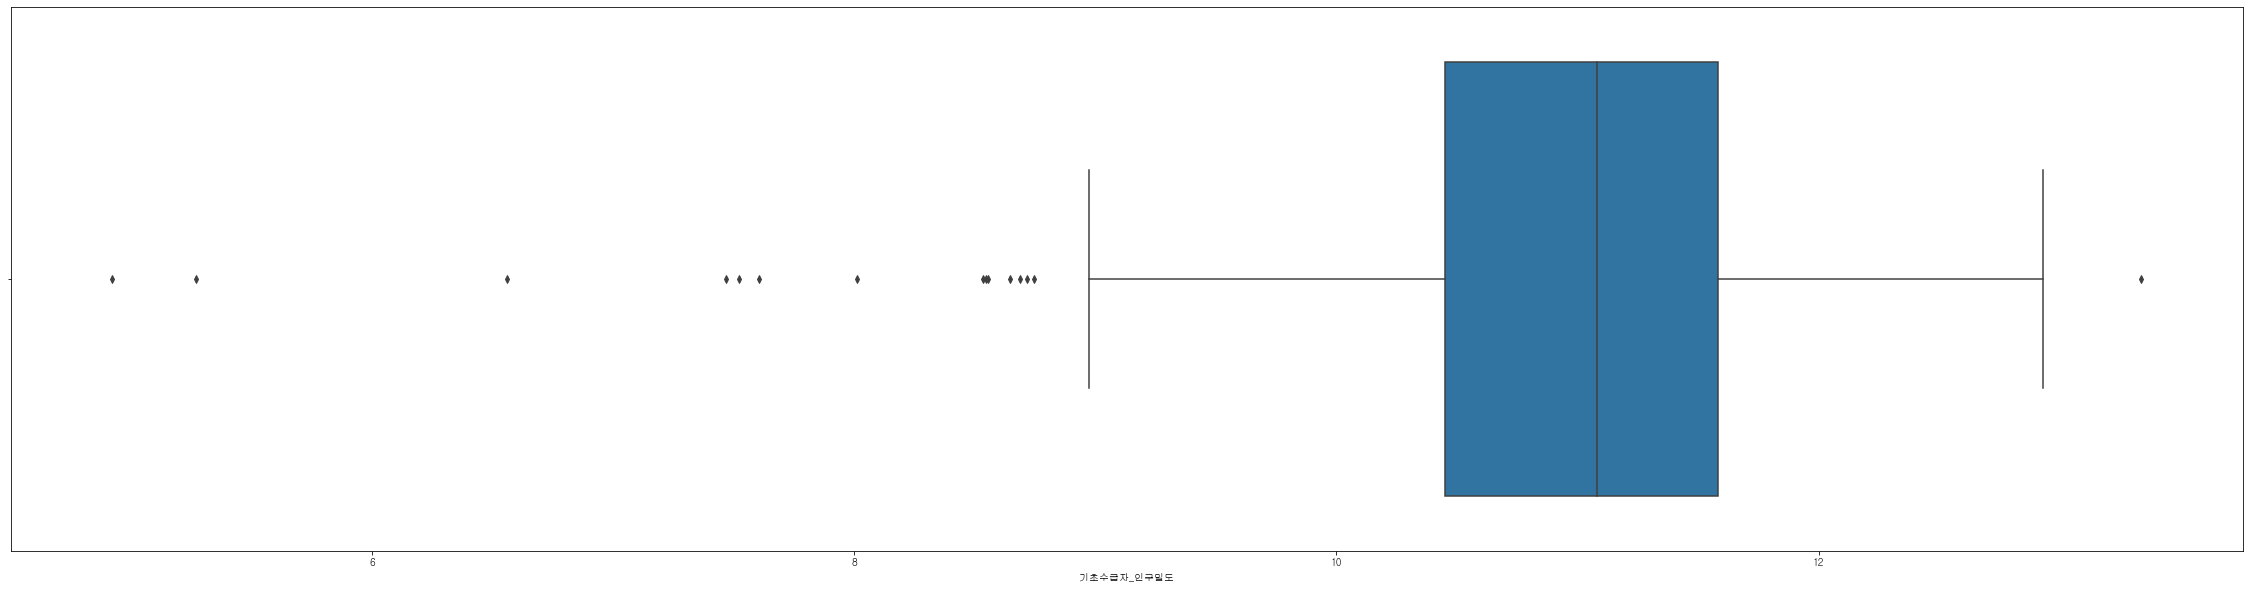

In [33]:
sns.boxplot(df2['기초수급자_인구밀도'])

In [39]:
df2[df2.기초수급자_인구밀도 == df2.기초수급자_인구밀도.max()]

,총생활인구,인당녹지면적,기초수급자_인구밀도
행정동,,,
등촌3동,15.780278,0.805751,13.338136


C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='총생활인구'>

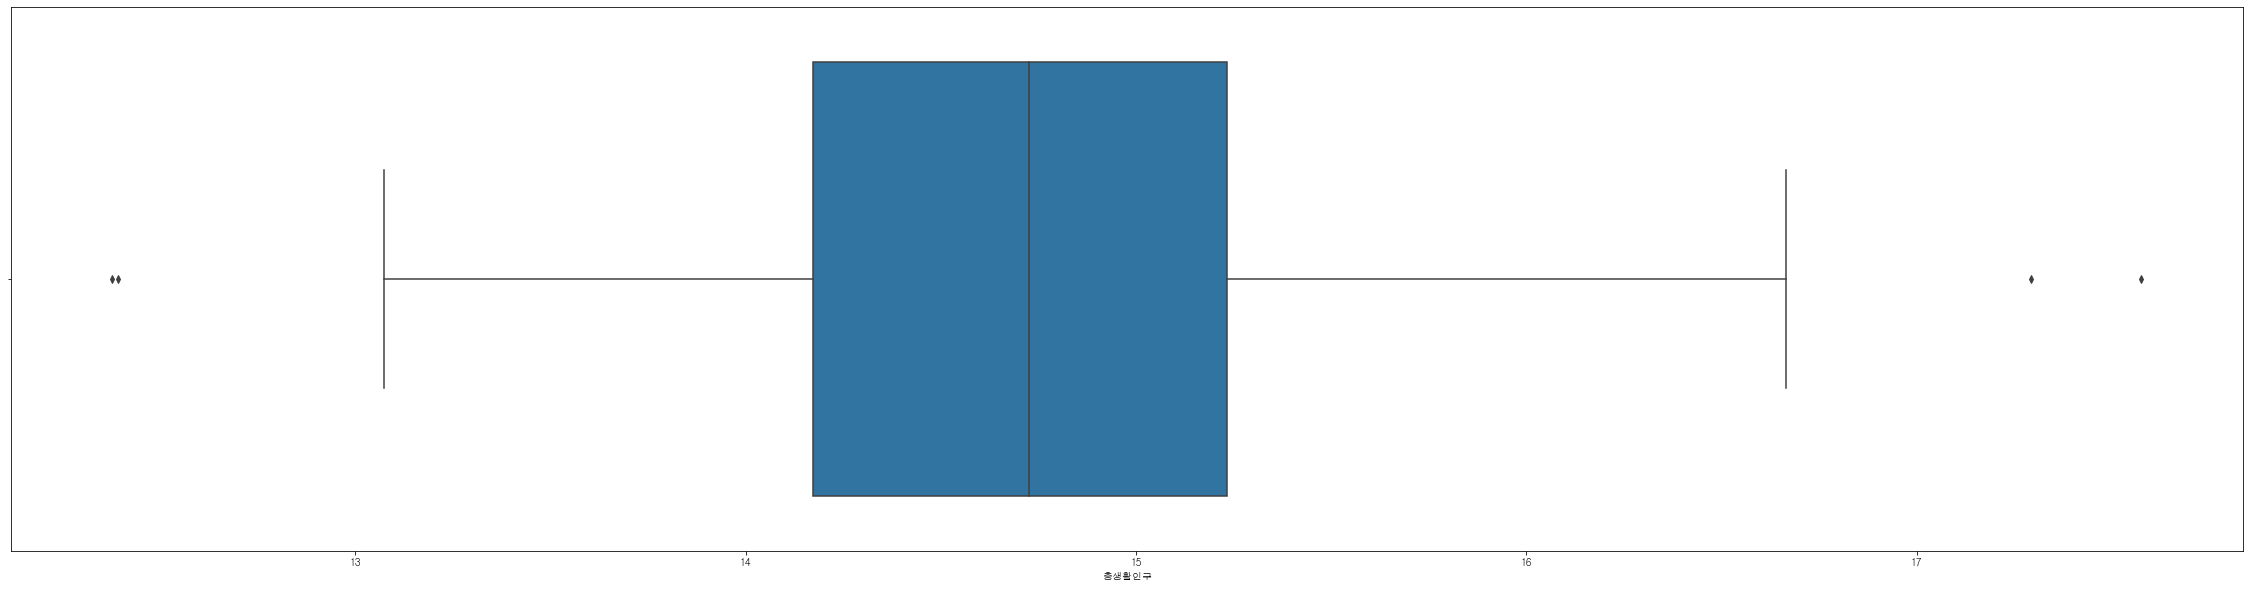

In [36]:
sns.boxplot(df2['총생활인구'])

In [17]:
df = df[df.인당녹지면적 != df.인당녹지면적.max()]
df = df[df.인당녹지면적 != df.인당녹지면적.max()]

In [11]:
import numpy as np
df['인당녹지면적'] = np.log1p(df['인당녹지면적'])

In [19]:
df

,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,대중교통,도시재생사업수,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,평균기온(°C),공시지가
0,13187,서울특별시,중랑구,면목2동,1107052,11260102,상봉동,10007.653660,1,2227.272727,0.002711,41336.27429,19,38,0.115378,0.2,3053235.294
1,13190,서울특별시,중랑구,면목2동,1107052,11260101,면목동,10007.655520,1,2227.272727,0.002711,41336.27429,19,38,0.196591,0.2,3554822.222
2,13194,서울특별시,중랑구,면목2동,1107052,11260101,면목동,6480.509401,1,2227.272727,0.002711,41336.27429,19,38,0.196591,0.2,3612395.349
3,13195,서울특별시,중랑구,면목2동,1107052,11260101,면목동,5857.305252,1,2227.272727,0.002711,41336.27429,19,38,0.196591,0.2,3186083.333
4,13197,서울특별시,중랑구,면목2동,1107052,11260101,면목동,6094.001933,1,2227.272727,0.002711,41336.27429,19,38,0.196591,0.2,3181000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11505,71476,서울특별시,송파구,위례동,1124082,11710109,장지동,4617.266177,0,1816.666667,0.001029,84263.96095,19,38,2.287588,0.6,5844666.667
11506,71477,서울특별시,송파구,위례동,1124082,11710109,장지동,214.748286,0,1816.666667,0.001029,84263.96095,19,38,2.287588,0.6,8020333.333
11507,71478,서울특별시,송파구,위례동,1124082,11710113,거여동,0.000000,0,1816.666667,0.001029,84263.96095,19,38,2.134554,0.6,4698000.000
11508,71479,서울특별시,송파구,위례동,1124082,11710113,거여동,0.000000,0,1816.666667,0.001029,84263.96095,19,38,2.134554,0.6,4080600.000


{'whiskers': [<matplotlib.lines.Line2D at 0x237178e1df0>,
 'caps': [<matplotlib.lines.Line2D at 0x237178f13d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x237178e1b20>,
 'medians': [<matplotlib.lines.Line2D at 0x237178f1970>,
 'fliers': [<matplotlib.lines.Line2D at 0x237178f1c40>,
 'means': []}

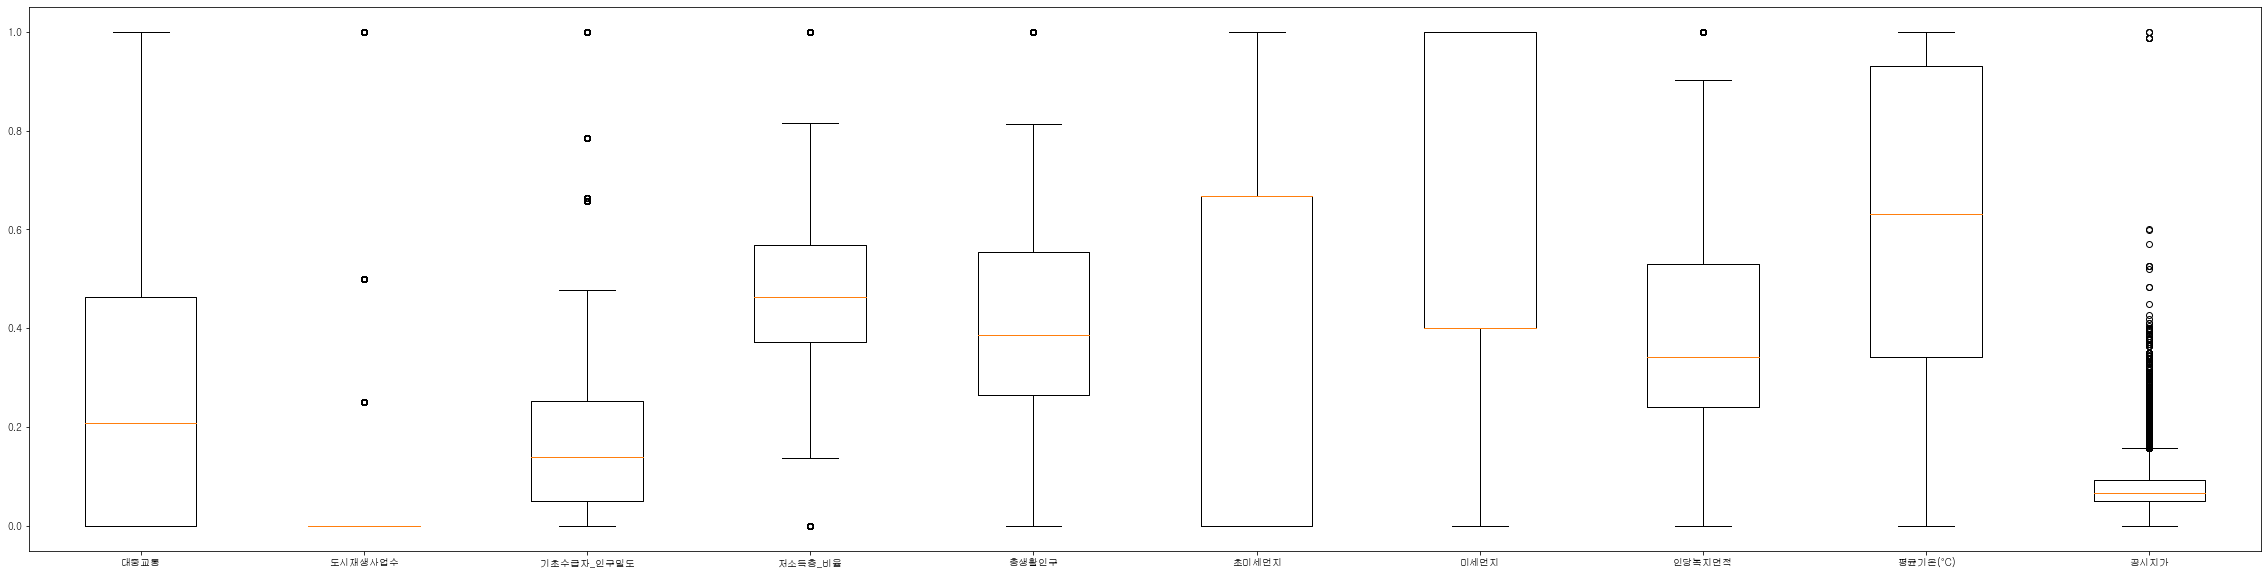

In [18]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

<기준>
- 도시재생사업수: 안뺌
- 대중교통은 2/3가 0이어서 이상치를 측정할 수 없었음. 그래서 0빼고 박스플랏 그려봤더니 이상치 없었음.
- 기초수급자 인구밀도,총생활인구수: 너무 높은 이상치 두 개 제거
- 저소득층: 이상치 전부 제거
- 인당녹지면적: 이상치 전부제거(인당녹지면적이 높은 곳은 후보지에서 제외)
- 공시지가: 이상치 전부제거 (공시지가가 너무 높은 곳은 후보지에서 제외)

### 이상치 제거

#### 1. 기초수급자_인구밀도

max이상치 행정동: ['사직동', '삼청동', '가회동', '종로1·2·3·4가동', '소공동', '회현동', '명동', '필동', '장충동', '광희동', '남영동', '증산동', '수색동', '상암동', '공항동', '방화2동', '방화3동','사당2동', '방배본동', '양재2동', '내곡동']

In [156]:
# 가장 큰 값 제거 - 2번
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]

#### 2. 저소득층_비율
max이상치 행정동: ['화곡1동', '상도1동', '역삼1동', '길동']  
min이상치 행정동: ['소공동', '가락1동']

In [157]:
# 가장 큰 값 제거 - 1번
df = df[df.저소득층_비율 != df.저소득층_비율.max()]

In [159]:
import numpy as np

df['저소득층_비율'] = np.log1p(df['저소득층_비율'])
quantile_25 = np.quantile(df['저소득층_비율'], 0.25)
quantile_75 = np.quantile(df['저소득층_비율'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(df['저소득층_비율'] > minimum)]

#### 3. 총생활인구
max이상치 행정동: ['역삼1동']  
min이상치 행정동: ['삼청동', '창신3동', '신월6동', '반포본동', '둔촌1동']

In [161]:
df = df[df.총생활인구 != df.총생활인구.max()]
df = df[df.총생활인구 != df.총생활인구.max()]

#### 4. 인당녹지면적  
max = 4.310339892515737

In [163]:
import numpy as np

df['인당녹지면적'] = np.log1p(df['인당녹지면적'])
quantile_25 = np.quantile(df['인당녹지면적'], 0.25)
quantile_75 = np.quantile(df['인당녹지면적'],0.75)

IQR = quantile_75 - quantile_25

maximum = quantile_75 + 1.5 * IQR

df = df[(df['인당녹지면적'] <= maximum)]

# 공시지가

In [165]:
import numpy as np
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])
quantile_25 = np.quantile(df['총공시지가평균'], 0.25)
quantile_75 = np.quantile(df['총공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['총공시지가평균']) & (df['총공시지가평균'] <= maximum)]

In [166]:
df['토지공시지가평균'] = np.log1p(df['토지공시지가평균'])
quantile_25 = np.quantile(df['토지공시지가평균'], 0.25)
quantile_75 = np.quantile(df['토지공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['토지공시지가평균']) & (df['토지공시지가평균'] <= maximum)]

In [167]:
df['임야공시지가평균'] = np.log1p(df['임야공시지가평균'])
quantile_25 = np.quantile(df['임야공시지가평균'], 0.25)
quantile_75 = np.quantile(df['임야공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['임야공시지가평균']) & (df['임야공시지가평균'] <= maximum)]

In [169]:
import numpy as np
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])
quantile_25 = np.quantile(df['총공시지가평균'], 0.25)
quantile_75 = np.quantile(df['총공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['총공시지가평균']) & (df['총공시지가평균'] <= maximum)]

In [63]:
df2.reset_index(drop=True,inplace=True)

In [80]:
df2

,총생활인구,인당녹지면적,기초수급자_인구밀도
행정동,,,
가락1동,53481.18571,0.924458,83.582090
가락2동,49474.56286,1.046944,600.000000
가락본동,75267.14762,1.039169,653.982301
가양1동,98459.54190,2.448276,65.319149
가양2동,29146.41477,2.081538,3330.000000
...,...,...,...
화곡3동,39697.45905,1.820956,1277.358491
화곡4동,32927.02381,1.760130,1497.560976
화곡6동,39817.28714,1.765346,918.018018


In [81]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df2) 

# 결과

{'whiskers': [<matplotlib.lines.Line2D at 0x2371e9a9d60>,
 'caps': [<matplotlib.lines.Line2D at 0x2371e9b9340>,
 'boxes': [<matplotlib.lines.Line2D at 0x2371e9a9a60>,
 'medians': [<matplotlib.lines.Line2D at 0x2371e9b98e0>,
 'fliers': [<matplotlib.lines.Line2D at 0x2371e9b9bb0>,
 'means': []}

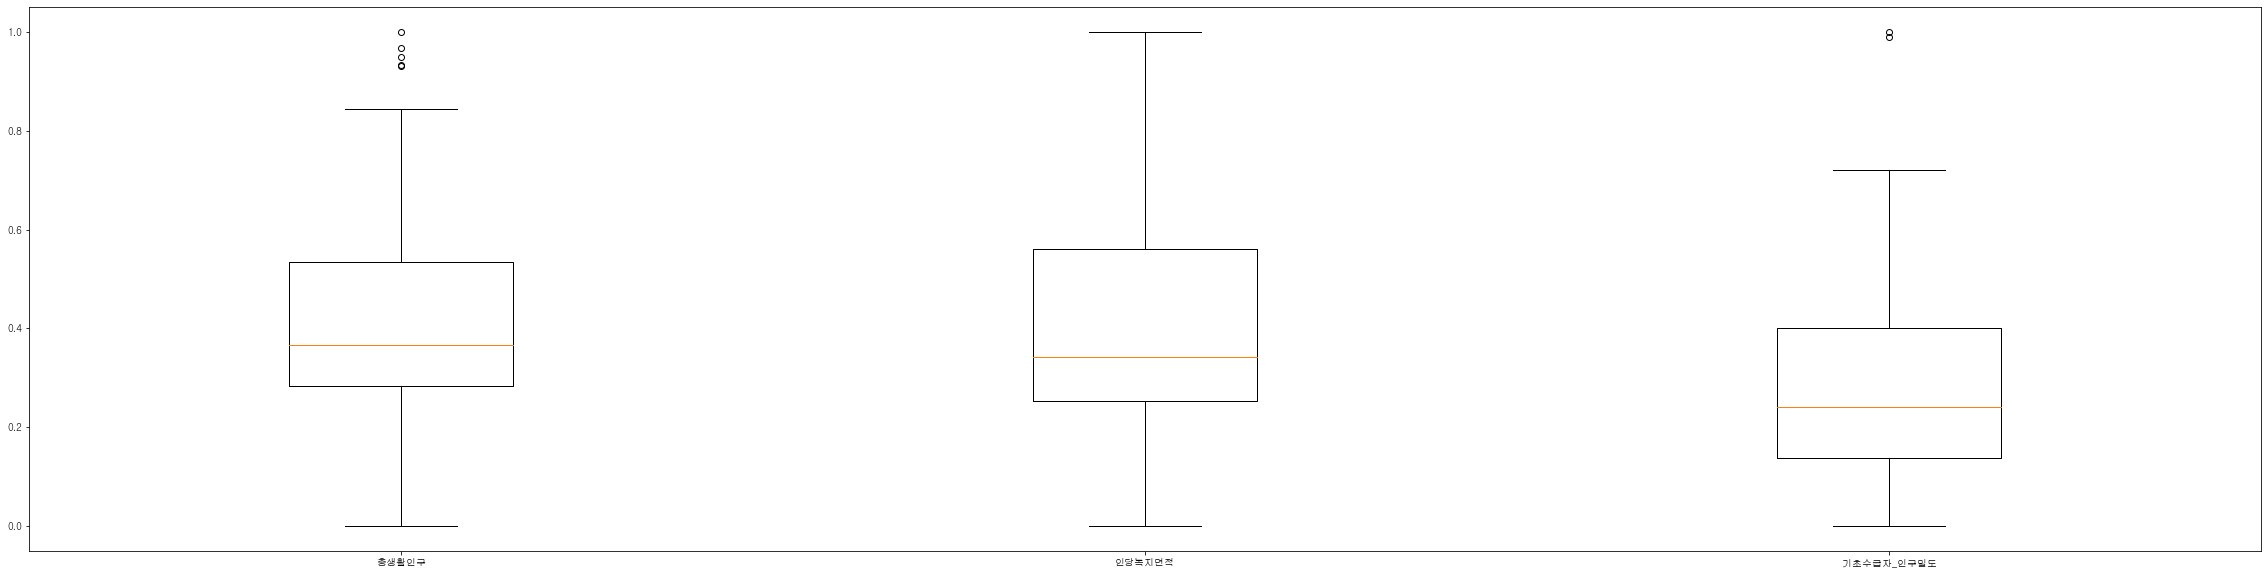

In [82]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df2) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df2.columns)

In [65]:
minMaxScaled_data

array([[2.36741248e-01, 1.15876046e-02],
       [2.75858539e-01, 8.56998936e-02],
       [2.73375647e-01, 9.34470143e-02],
       [7.23389833e-01, 8.96664913e-03],
       [6.06267860e-01, 4.77488298e-01],
       [6.07024203e-01, 6.63193131e-01],
       [2.57979825e-01, 2.65755967e-01],
       [1.97320861e-01, 2.17252777e-01],
       [6.24001659e-01, 1.57174615e-01],
       [6.25014289e-01, 2.17027129e-01],
       [3.43903354e-01, 2.48652440e-01],
       [3.44711532e-01, 1.98989021e-02],
       [7.93133545e-01, 2.29743524e-02],
       [1.63891726e-01, 1.59327910e-01],
       [2.80596502e-01, 2.76627867e-02],
       [2.86183636e-01, 3.20701180e-01],
       [2.86183636e-01, 1.16913805e-01],
       [3.55952741e-01, 1.56115019e-02],
       [3.91849197e-01, 1.39817636e-01],
       [1.73596652e-01, 2.68889042e-01],
       [2.86183636e-01, 2.29867756e-02],
       [3.35016615e-01, 2.59744459e-02],
       [3.27338703e-01, 1.86158459e-01],
       [2.66274149e-01, 6.88820535e-02],
       [1.948126

In [90]:
data_df = pd.DataFrame(minMaxScaled_data,columns = df2.columns.to_list(),index=df2.index).reset_index()
data_df

,행정동,총생활인구,인당녹지면적,기초수급자_인구밀도
0,가락1동,0.504039,0.236741,0.017472
1,가락2동,0.459859,0.275859,0.129223
2,가락본동,0.744265,0.273376,0.140905
3,가양1동,1.000000,0.723390,0.013520
4,가양2동,0.235707,0.606268,0.719984
...,...,...,...,...
155,화곡3동,0.352050,0.523048,0.275801
156,화곡4동,0.277395,0.503623,0.323452
157,화곡6동,0.353371,0.505288,0.198041
158,화곡8동,0.585325,0.509934,0.466882


In [91]:
data_df.to_csv('2차군집화_스케일링.csv',encoding='cp949',index=False)